
# 📊 CPSC 4800 Lab 5 – Question 3

This analysis investigates the effectiveness of an incentive program designed to increase user engagement. We compare users from the incentive group with those from the normal group in terms of:
- Subscription status (active vs inactive)
- Recent pageview activity
- Overall engagement behavior

We aim to determine if the incentive program leads to statistically significant differences in user activity.


# CPSC 4800 Lab 5
# Question 3

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Lab5_media.csv')

gincent = df.iloc[:2500]
gnormal = df.iloc[2500:]

gnormal[:4]

,Subscription_Id,User_Id,Subscription_Status,Publication_Name,Inactive,Start_Date,End_Date,Charge_Count,Renewal_Type,Account_Tenure,Days_Since_Last_Session,Pageviews_First_7_Days,Pageviews_Total_Within_Term,Avg_Monthly_Pageviews_Within_Term,Pageviews_Last_30Days,Pageviews_Last_7Days
2500,RCZ9T0B6SW2W,1f22b415-a44e-46a8-9dfb-408f094f5b3d,Active,Toronto Sun,False,2022-09-16 17:34:13 UTC,NaN,8,Monthly,202,4,37,1283,190.544555,151,3
2501,RCM75E9ZE6EM,25d7498282874e48ac59ae9f0f997cd4,Expired,Windsor Star,True,2022-06-01 21:25:18 UTC,2023-02-08 10:11:53 UTC,9,Monthly,252,0,23,50,5.976096,6,6
2502,RC2R59MRULIE,3460fa2a-e27a-49ee-b022-11b00e33a96a,Payment failed,Toronto Sun,True,2022-05-04 19:00:57 UTC,2022-12-29 08:51:20 UTC,8,Monthly,239,7,57,706,88.991597,87,0
2503,RC6UX4URSFE1,36b12dd4-3851-44bf-98c1-15dd068e4f4f,Active,Toronto Sun,False,2022-09-17 19:18:09 UTC,NaN,8,Monthly,201,1,76,2384,355.820896,377,59


In [2]:
print(gincent.info())
print(gnormal.info())
print(gincent.describe())
print(gnormal.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 16 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Subscription_Id                    2500 non-null   object 
 1   User_Id                            2500 non-null   object 
 2   Subscription_Status                2500 non-null   object 
 3   Publication_Name                   2500 non-null   object 
 4   Inactive                           2500 non-null   bool   
 5   Start_Date                         2500 non-null   object 
 6   End_Date                           955 non-null    object 
 7   Charge_Count                       2500 non-null   int64  
 8   Renewal_Type                       2500 non-null   object 
 9   Account_Tenure                     2500 non-null   int64  
 10  Days_Since_Last_Session            2500 non-null   int64  
 11  Pageviews_First_7_Days             2500 non-null   int64

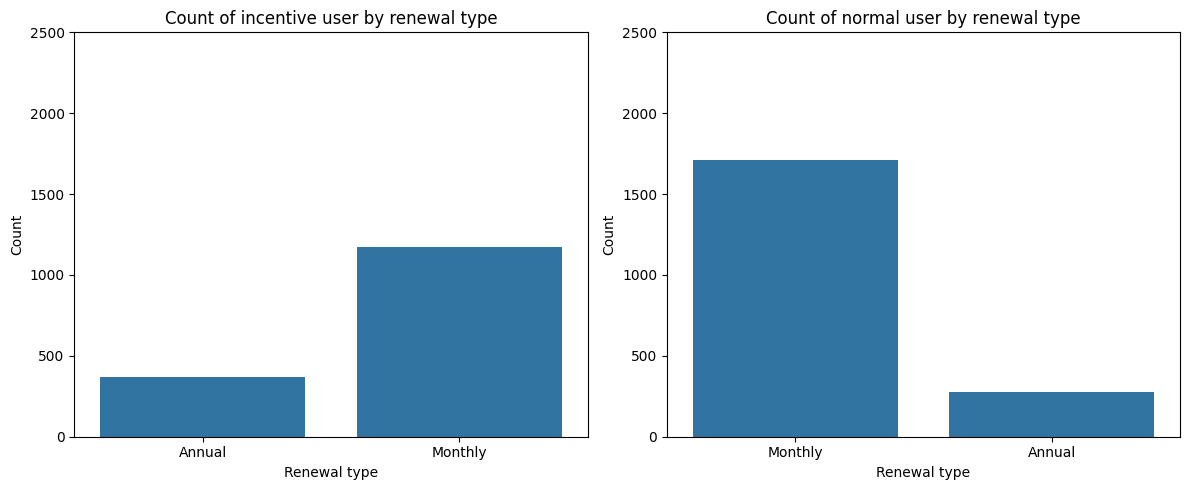

In [3]:
gincent_active = gincent[gincent['Subscription_Status'] == 'Active']
gnormal_active = gnormal[gnormal['Subscription_Status'] == 'Active']

# Set up a 1x2 grid of subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Count of user by subscription status
sns.countplot(x='Renewal_Type', data=gincent_active, ax=axs[0])
axs[0].set_title('Count of incentive user by renewal type')
axs[0].set_xlabel('Renewal type')
axs[0].set_ylabel('Count')
axs[0].set_ylim(0, 2500)

# Plot 2: Count of user by subscription status
sns.countplot(x='Renewal_Type', data=gnormal_active, ax=axs[1])
axs[1].set_title('Count of normal user by renewal type')
axs[1].set_xlabel('Renewal type')
axs[1].set_ylabel('Count')
axs[1].set_ylim(0, 2500)

# Adjust layout
plt.tight_layout()

plt.show()

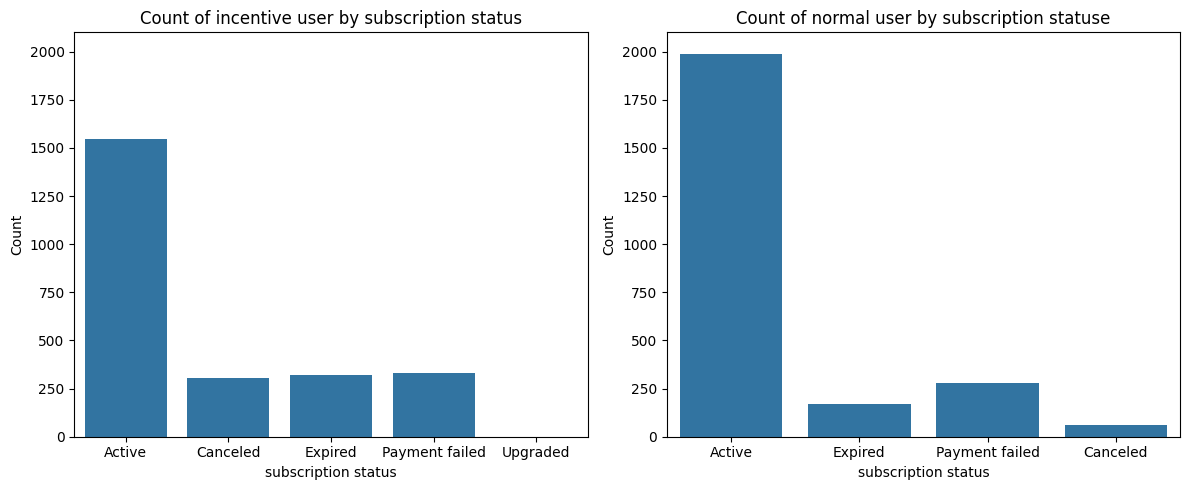

In [4]:
# Set up a 1x2 grid of subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Count of user by subscription status
sns.countplot(x='Subscription_Status', data=gincent, ax=axs[0])
axs[0].set_title('Count of incentive user by subscription status')
axs[0].set_xlabel('subscription status')
axs[0].set_ylabel('Count')
axs[0].set_ylim(0, 2100)

# Plot 2: Count of user by subscription status
sns.countplot(x='Subscription_Status', data=gnormal, ax=axs[1])
axs[1].set_title('Count of normal user by subscription statuse')
axs[1].set_xlabel('subscription status')
axs[1].set_ylabel('Count')
axs[1].set_ylim(0, 2100)

# Adjust layout
plt.tight_layout()

plt.show()

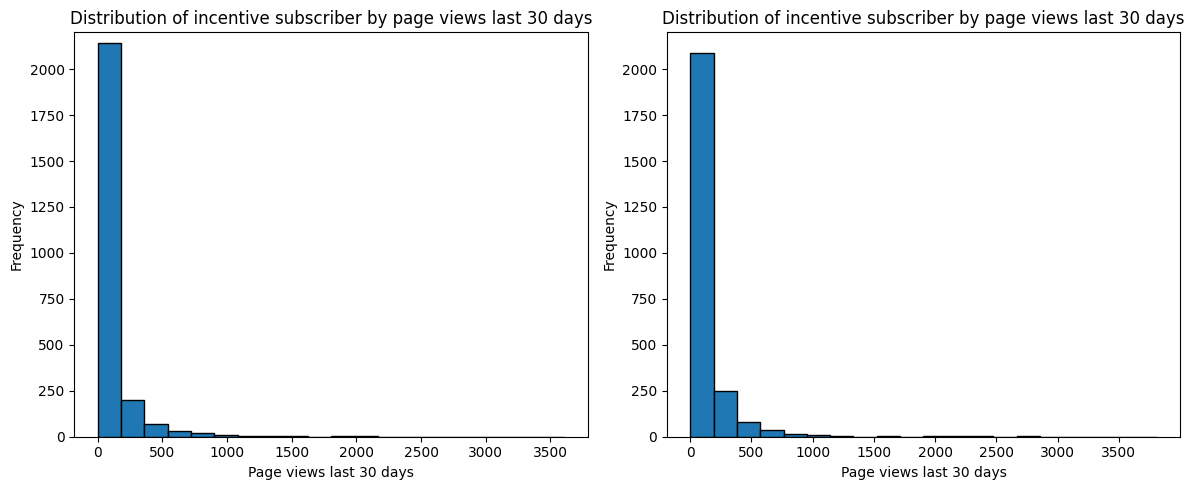

In [5]:
# Set up a 1x2 grid of subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Distribution of user by Pageviews_Last_7Days
axs[0].hist(gincent['Pageviews_Last_30Days'], bins=20, edgecolor='black')
axs[0].set_title('Distribution of incentive subscriber by page views last 30 days')
axs[0].set_xlabel('Page views last 30 days')
axs[0].set_ylabel('Frequency')
axs[0].set_ylim(0, 2200)

# Plot 2: Distribution of user by Pageviews_Last_7Days
axs[1].hist(gnormal['Pageviews_Last_30Days'], bins=20, edgecolor='black')
axs[1].set_title('Distribution of incentive subscriber by page views last 30 days')
axs[1].set_xlabel('Page views last 30 days')
axs[1].set_ylabel('Frequency')
axs[1].set_ylim(0, 2200)
# Adjust layout
plt.tight_layout()

plt.show()

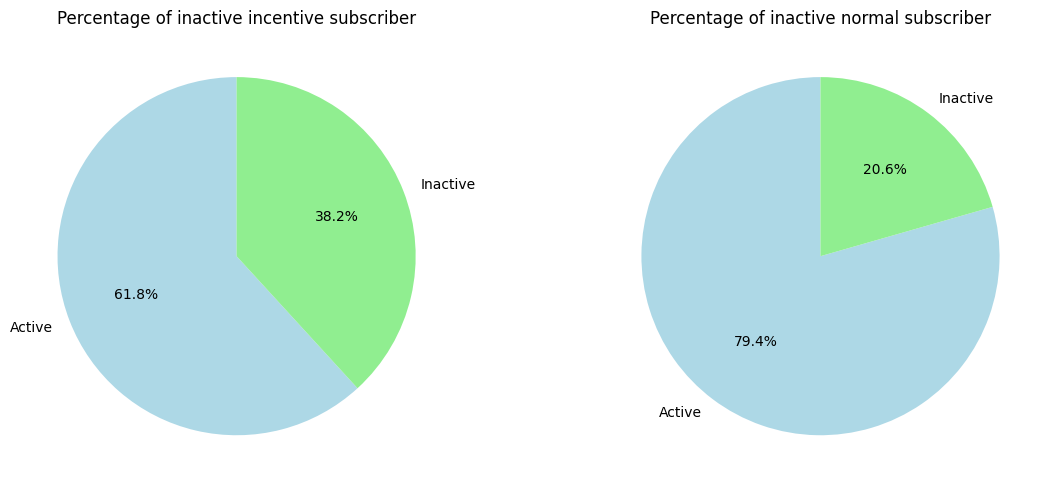

In [6]:
# Set up a 1x2 grid of subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

labels1= ['Active','Inactive']
# Plot 1: Percentage of Inactive Subscriber
icounts = gincent['Inactive'].value_counts()

axs[0].pie(icounts, labels=labels1, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightgreen'])
#axs[0].pie(icounts, labels=species_counts.index, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightgreen'])
axs[0].set_title('Percentage of inactive incentive subscriber')

# Plot 1: Percentage of Inactive Subscriber
ncounts = gnormal['Inactive'].value_counts()
axs[1].pie(ncounts, labels=labels1, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightgreen'])
axs[1].set_title('Percentage of inactive normal subscriber')

# Adjust layout
plt.tight_layout()

plt.show()

In [7]:
from scipy import stats

gincent_active = gincent[gincent['Subscription_Status'] == 'Active']
gnormal_active = gnormal[gnormal['Subscription_Status'] == 'Active']

gincent_PR30D = gincent_active['Pageviews_Last_30Days']
gnormal_PR30D = gnormal_active['Pageviews_Last_30Days']

t_stat_incentive, p_value_incentive = stats.ttest_ind(gincent_PR30D, gnormal_PR30D, equal_var=False)

print(f"T-statistic: {t_stat_incentive:.4f}")
print(f"P-value: {p_value_incentive:.4f}")

T-statistic: -1.6359
P-value: 0.1020



## ✅ Conclusion

Based on the analysis:

- There are **more active users** with monthly renewals in the **normal user group** than in the incentive group.
- The **incentive group has a higher percentage of inactive accounts**, suggesting the program may not retain users effectively.
- A **t-test** comparing the `Pageviews_Last_30Days` between active subscribers in both groups yielded a **p-value > 0.05**.
  → This indicates **no statistically significant difference**, and hence, the **incentive program does not show measurable effectiveness** in increasing engagement.
